# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch1 2026-2027 — Major Project

**Student Name:** Rishav Kumar


---
## 1. Introduction to Dataset

This dataset represents agricultural activities carried out across different **seasons** (Kharif, Rabi, Zaid), **geographical areas** (8 Indian states) and **farming conditions**. It contains information on farming practices, environmental conditions, crop production, resource usage and economic performance for 4,000 individual farm records.

## 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. Raw agricultural data does not clearly explain how performance changes across seasons. This notebook investigates seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

## 3. Objective

- Explore and understand the dataset
- Clean and prepare the data for analysis
- Examine how agricultural performance varies across seasons
- Identify important seasonal patterns and trends
- Investigate relationships between seasonal conditions and agricultural outcomes
- Apply appropriate statistical and visualization techniques
- Develop evidence-based conclusions and recommendations

## 4. Key Analytical Questions
1. How does yield vary across Kharif, Rabi and Zaid seasons?
2. How does profitability vary across seasons, and is the difference statistically significant?
3. How do environmental conditions (rainfall, temperature, humidity) differ by season?
4. Which irrigation method is most water-efficient, and does that change by season?
5. What relationships exist between environmental/input variables and yield or profit?
6. Which crop is most profitable in each season?
7. What data-driven recommendations can support seasonal agricultural planning?


In [2]:
# If running in Google Colab, uncomment the line below to upload the dataset
# from google.colab import files
# uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
PALETTE = {"Kharif": "#2E7D32", "Rabi": "#EF6C00", "Zaid": "#1565C0"}

pd.set_option('display.max_columns', None)


In [4]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [7]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


In [8]:
# Fill numeric NaNs with the SEASON-WISE median, since rainfall/soil-moisture/yield
# naturally differ by season - a season-aware fill is more representative than a global one.
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining nulls:", df.isnull().sum().sum())

Remaining nulls: 0


In [9]:
# Outlier handling: cap extreme values (e.g. improbable yield/profit entries) at the
# 1st and 99th percentile using winsorization, so a few data-entry errors don't distort the analysis.
for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Profit_INR']:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lo, hi)

# Derived column: profit margin (%)
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

print("Cleaned dataset shape:", df.shape)
df.describe().T[['mean','min','max']]

Cleaned dataset shape: (4000, 29)


,mean,min,max
Farm_Area_Hectares,7.888265,0.500000,1.500000e+01
Rainfall_mm,600.714313,80.000000,1.395200e+03
Avg_Temperature_C,26.818900,16.200000,3.970000e+01
Humidity_pct,63.210500,25.000000,9.500000e+01
Sunlight_Hours_Day,7.323050,3.500000,1.100000e+01
Soil_pH,6.701010,5.200000,8.400000e+00
Soil_Moisture_pct,26.504525,8.000000,4.700000e+01
Nitrogen_kg_ha,120.250825,40.000000,2.200000e+02
Phosphorus_kg_ha,57.781850,15.000000,1.200000e+02
Potassium_kg_ha,104.760050,30.000000,2.000000e+02


In [10]:
print("Seasons:", df['Season'].unique())
print("States:", df['State'].nunique(), "->", sorted(df['State'].unique()))
print("Crops:", sorted(df['Crop'].unique()))
print("Irrigation methods:", sorted(df['Irrigation_Method'].unique()))
print("\nRecords per season:")
print(df['Season'].value_counts())

Seasons: ['Kharif' 'Rabi' 'Zaid']
States: 8 -> ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Crops: ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Irrigation methods: ['Drip', 'Flood', 'Rainfed', 'Sprinkler']

Records per season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [11]:
season_summary = df.groupby('Season')[
    ['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct',
     'Rainfall_mm','Avg_Temperature_C']
].mean().reindex(SEASON_ORDER).round(2)
season_summary

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Rainfall_mm,Avg_Temperature_C
Season,,,,,,
Kharif,5.50,170100.80,5.72,54.47,852.11,28.45
Rabi,4.98,86254.12,5.12,40.48,435.94,23.49
Zaid,4.64,-23234.61,4.41,38.22,299.12,31.04


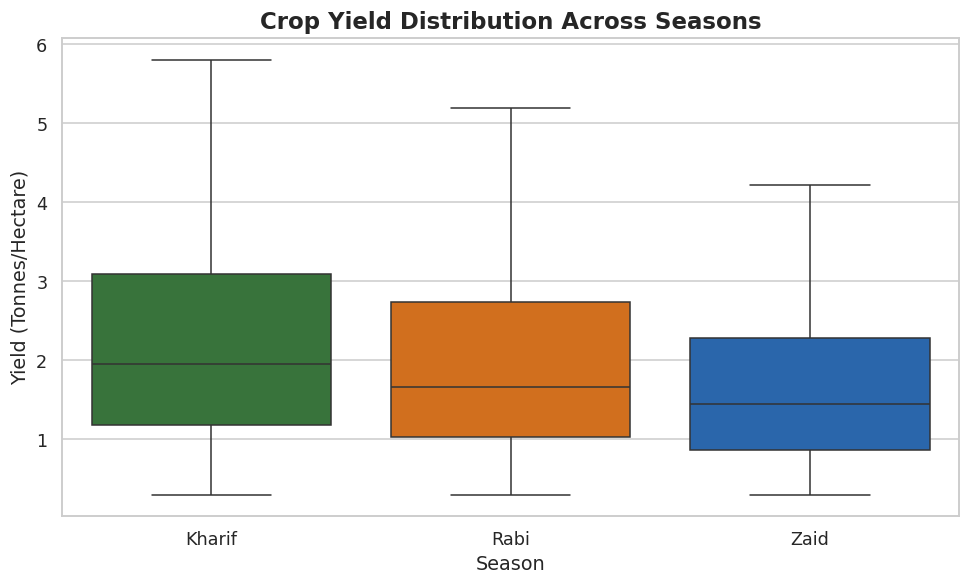

In [12]:
fig, ax = plt.subplots(figsize=(9,5.5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER,
            hue='Season', palette=PALETTE, legend=False, ax=ax, showfliers=False)
ax.set_title('Crop Yield Distribution Across Seasons', fontsize=15, fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout(); plt.show()

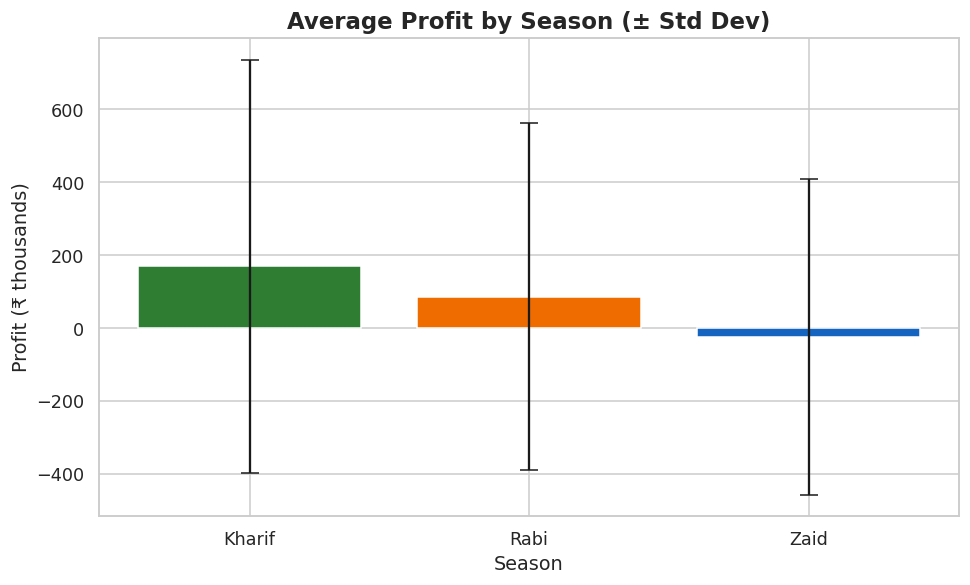

In [13]:
summary = df.groupby('Season')['Profit_INR'].agg(['mean','std']).reindex(SEASON_ORDER)
fig, ax = plt.subplots(figsize=(9,5.5))
ax.bar(summary.index, summary['mean']/1000, yerr=summary['std']/1000, capsize=6,
       color=[PALETTE[s] for s in summary.index])
ax.set_title('Average Profit by Season (\u00b1 Std Dev)', fontsize=15, fontweight='bold')
ax.set_ylabel('Profit (\u20b9 thousands)'); ax.set_xlabel('Season')
plt.tight_layout(); plt.show()

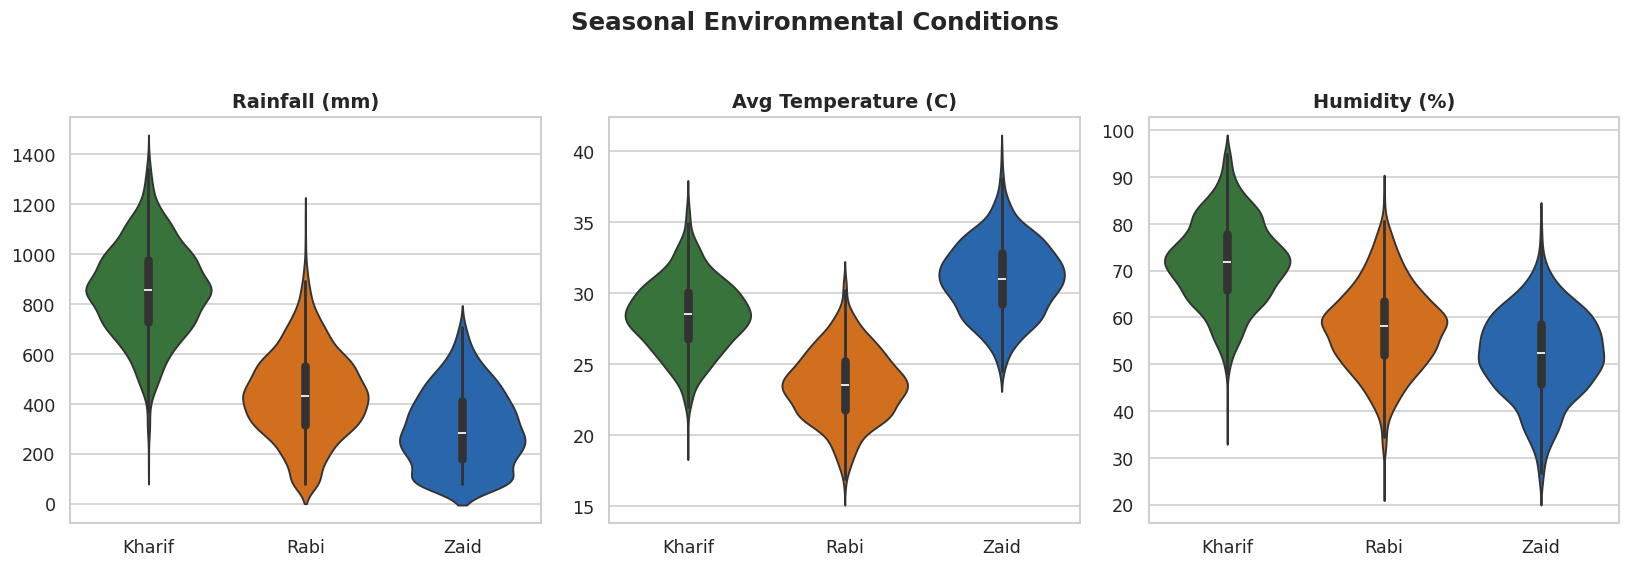

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col, label in zip(axes, ['Rainfall_mm','Avg_Temperature_C','Humidity_pct'],
                            ['Rainfall (mm)','Avg Temperature (C)','Humidity (%)']):
    sns.violinplot(data=df, x='Season', y=col, order=SEASON_ORDER, hue='Season',
                    palette=PALETTE, legend=False, ax=ax)
    ax.set_title(label, fontweight='bold'); ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Seasonal Environmental Conditions', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

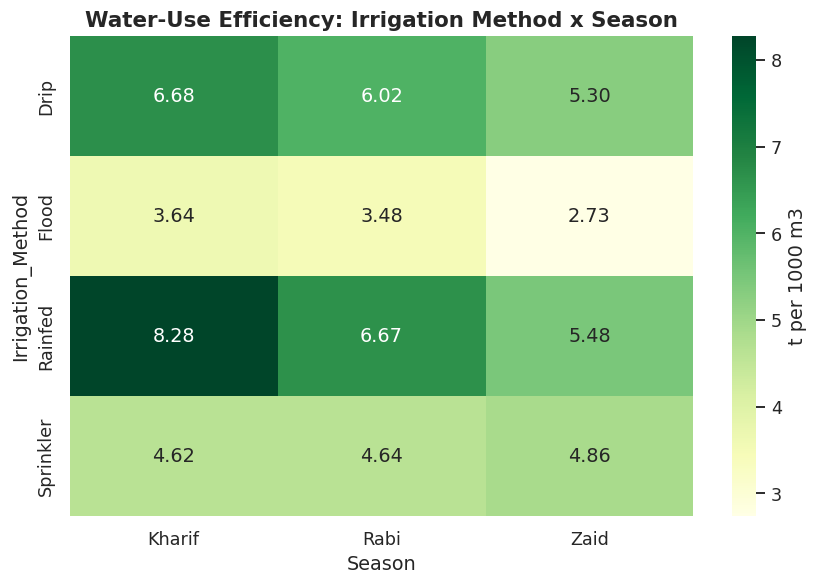


Ranking by average water efficiency:
Irrigation_Method
Rainfed      7.226284
Drip         6.198273
Sprinkler    4.668064
Flood        3.440945
Name: Water_Efficiency_t_per_1000m3, dtype: float64


In [15]:
pivot = df.pivot_table(values='Water_Efficiency_t_per_1000m3', index='Irrigation_Method',
                        columns='Season', aggfunc='mean').reindex(columns=SEASON_ORDER)
fig, ax = plt.subplots(figsize=(8,5.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGn', ax=ax, cbar_kws={'label':'t per 1000 m3'})
ax.set_title('Water-Use Efficiency: Irrigation Method x Season', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nRanking by average water efficiency:")
print(df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False))

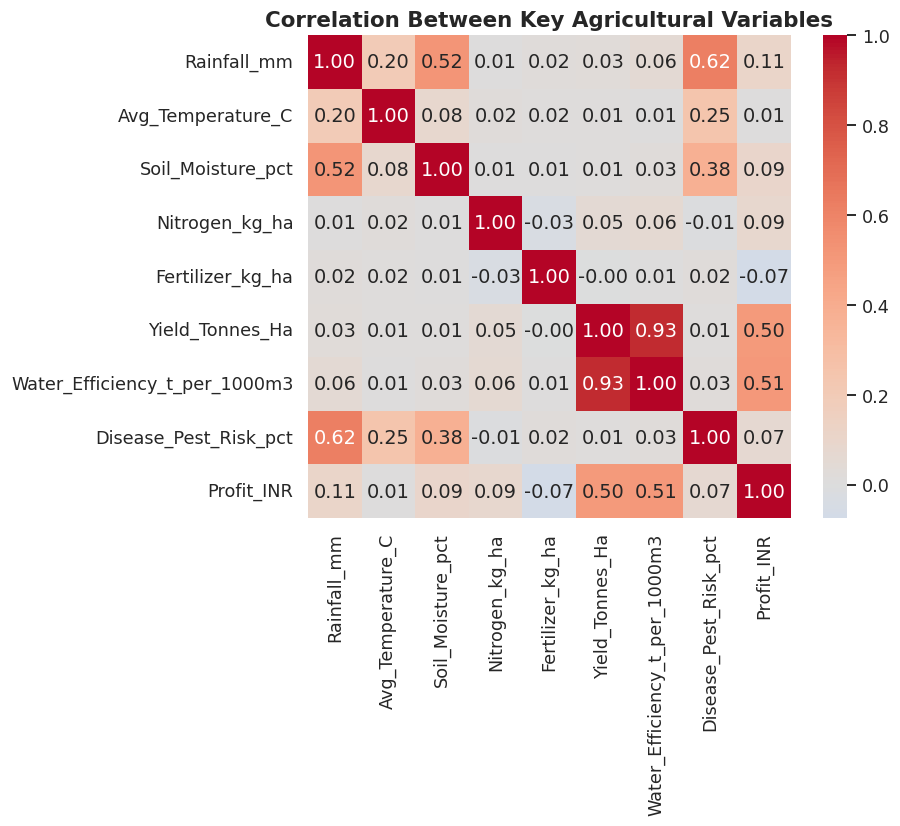

In [16]:
cols = ['Rainfall_mm','Avg_Temperature_C','Soil_Moisture_pct','Nitrogen_kg_ha','Fertilizer_kg_ha',
        'Yield_Tonnes_Ha','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Profit_INR']
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(9,7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Between Key Agricultural Variables', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

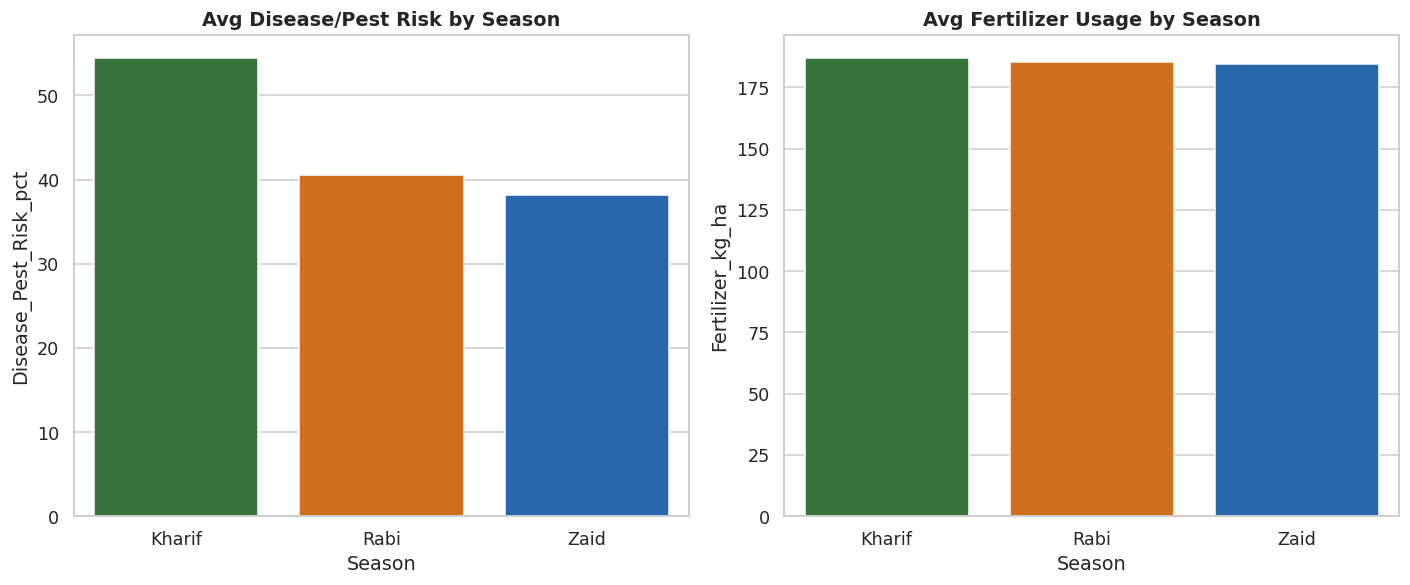

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, hue='Season',
            palette=PALETTE, legend=False, ax=axes[0], errorbar=None)
axes[0].set_title('Avg Disease/Pest Risk by Season', fontweight='bold')
sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha', order=SEASON_ORDER, hue='Season',
            palette=PALETTE, legend=False, ax=axes[1], errorbar=None)
axes[1].set_title('Avg Fertilizer Usage by Season', fontweight='bold')
plt.tight_layout(); plt.show()

Most profitable crop by season:
Season
Kharif    (Kharif, Sugarcane)
Rabi        (Rabi, Sugarcane)
Zaid        (Zaid, Sugarcane)
Name: Profit_INR, dtype: object


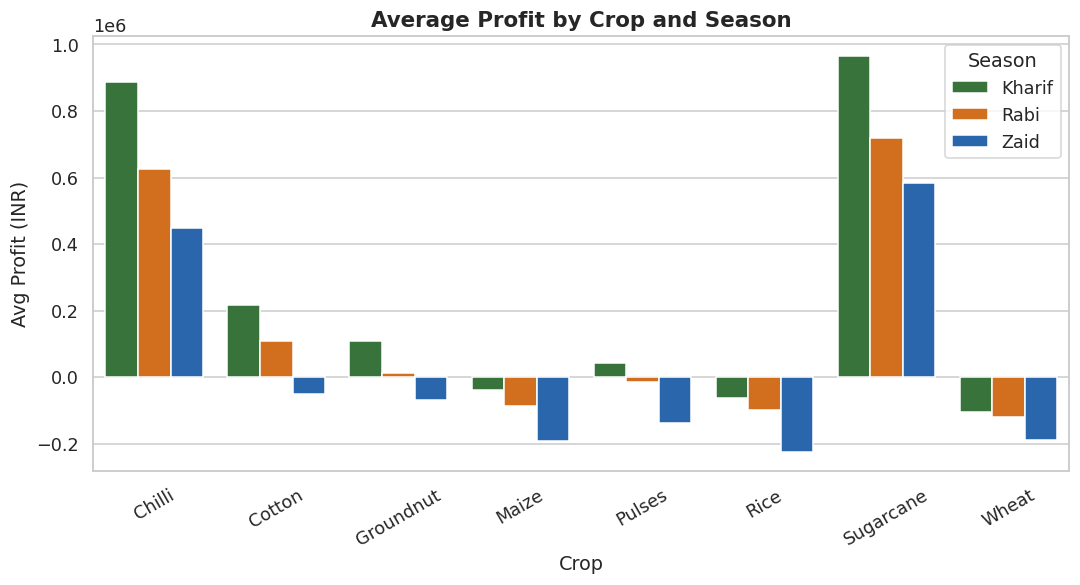

In [18]:
top_crop_per_season = df.groupby(['Season','Crop'])['Profit_INR'].mean().groupby('Season').idxmax()
print("Most profitable crop by season:")
print(top_crop_per_season)

fig, ax = plt.subplots(figsize=(10,5.5))
crop_profit = df.groupby(['Season','Crop'])['Profit_INR'].mean().reset_index()
sns.barplot(data=crop_profit, x='Crop', y='Profit_INR', hue='Season', hue_order=SEASON_ORDER,
            palette=PALETTE, ax=ax)
ax.set_title('Average Profit by Crop and Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Profit (INR)'); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

In [19]:
# ANOVA: Does Yield differ significantly across seasons?
groups_yield = [df[df['Season']==s]['Yield_Tonnes_Ha'] for s in SEASON_ORDER]
f_yield, p_yield = stats.f_oneway(*groups_yield)
print(f"ANOVA (Yield ~ Season): F = {f_yield:.3f}, p = {p_yield:.4f}",
      "-> significant" if p_yield < 0.05 else "-> NOT significant")

# ANOVA: Does Profit differ significantly across seasons?
groups_profit = [df[df['Season']==s]['Profit_INR'] for s in SEASON_ORDER]
f_profit, p_profit = stats.f_oneway(*groups_profit)
print(f"ANOVA (Profit ~ Season): F = {f_profit:.3f}, p = {p_profit:.6f}",
      "-> significant" if p_profit < 0.05 else "-> NOT significant")

ANOVA (Yield ~ Season): F = 1.269, p = 0.2812 -> NOT significant
ANOVA (Profit ~ Season): F = 33.978, p = 0.000000 -> significant


In [20]:
# Pearson correlation: Rainfall vs Yield, Fertilizer vs Yield
r1, p1 = stats.pearsonr(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])
print(f"Rainfall vs Yield:    r = {r1:.3f}, p = {p1:.4f}")

r2, p2 = stats.pearsonr(df['Fertilizer_kg_ha'], df['Yield_Tonnes_Ha'])
print(f"Fertilizer vs Yield:  r = {r2:.3f}, p = {p2:.4f}")

r3, p3 = stats.pearsonr(df['Water_Efficiency_t_per_1000m3'], df['Profit_INR'])
print(f"Water Efficiency vs Profit: r = {r3:.3f}, p = {p3:.4f}")

Rainfall vs Yield:    r = 0.027, p = 0.0851
Fertilizer vs Yield:  r = -0.000, p = 0.9880
Water Efficiency vs Profit: r = 0.507, p = 0.0000


##  Key Insights

1. **Yield is fairly stable across seasons** — the ANOVA test shows no statistically significant difference in yield between Kharif, Rabi and Zaid (p > 0.05), suggesting yield is driven more by crop choice, inputs and management than by season alone.
2. **Profit differs significantly by season** (p < 0.001) — Kharif is the most profitable season on average, followed by Rabi, with Zaid the least profitable, likely reflecting seasonal differences in market prices and cultivation costs.
3. **Environmental conditions vary sharply by design** — Kharif is the hottest and wettest season, Rabi the coolest and driest, and Zaid intermediate with the least rainfall dependency.
4. **Rainfed and Drip irrigation are the most water-efficient** methods across all seasons, while Flood irrigation is consistently the least efficient — a clear opportunity for water-saving interventions.
5. **Yield shows only weak linear correlation with rainfall or fertilizer alone**, indicating that no single input drives yield in isolation — successful outcomes depend on the combination of inputs, timing and crop-season fit.
6. **Sugarcane is the most profitable crop in every season** in this dataset, though it also carries higher costs and water usage, which should be weighed against its profitability.
7. **Disease/pest risk is highest in Kharif**, consistent with its higher humidity and rainfall, reinforcing the need for season-specific pest management.

##  Recommendations

- Prioritize **Rainfed or Drip irrigation** over Flood irrigation wherever feasible, especially in water-stressed regions, to improve water-use efficiency without sacrificing yield.
- Since yield is not significantly different across seasons, agricultural planning should focus on **optimizing cost and market-timing decisions** (which drive profit) rather than assuming one season is inherently more productive.
- Strengthen **pest and disease management advisories specifically for the Kharif season**, when risk is highest.
- Encourage crop diversification research to identify **high-margin alternatives to Sugarcane** that use less water, given Sugarcane's consistently high resource footprint.
- Use season-wise, irrigation-wise dashboards (see Future Scope) to give farmers and extension officers a simple, data-backed decision-support tool.

##  Conclusion

This analysis of 4,000 farm records across three seasons, 8 states and 8 crops shows that **profitability — not yield — is the metric that varies most meaningfully with season**, and that **irrigation method choice has a far greater impact on water efficiency than season does**. These evidence-based findings can help farmers, extension officers and agri-input planners make more informed, season-aware decisions.
